# 🦠 COVID-19 Global Data — Exploratory Data Analysis
**Horizon TechX AI & Data Science Internship | Task 3**  
**Author:** Mani Chelluri (Velzin)  
**Dataset:** Our World in Data — COVID-19 Dataset (Jan 2020 – Aug 2024)  
**Stack:** Python · Pandas · NumPy · Matplotlib · Seaborn

---

## 📌 Objective
Perform a comprehensive EDA on the global COVID-19 dataset to uncover trends, patterns,
and insights across countries, continents, and time.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'       : 120,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False
})

PALETTE = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653']
CONT_COLORS = {
    'Asia'          : '#E63946',
    'Europe'        : '#457B9D',
    'North America' : '#2A9D8F',
    'South America' : '#E9C46A',
    'Africa'        : '#F4A261',
    'Oceania'       : '#264653'
}
print('Imports loaded.')


Imports loaded.


## 1️⃣  Load & Clean the Dataset

In [2]:
df_raw = pd.read_csv('owid-covid-data.csv', parse_dates=['date'])
print('Raw shape:', df_raw.shape)
print('Date range:', df_raw['date'].min().date(), '->', df_raw['date'].max().date())
df_raw[['location','continent','date','total_cases','total_deaths']].head(4)


Raw shape: (429435, 67)
Date range: 2020-01-01 -> 2024-08-14


,location,continent,date,total_cases,total_deaths
0,Afghanistan,Asia,2020-01-05,0.0,0.0
1,Afghanistan,Asia,2020-01-06,0.0,0.0
2,Afghanistan,Asia,2020-01-07,0.0,0.0
3,Afghanistan,Asia,2020-01-08,0.0,0.0


In [3]:
# Keep country-level rows only
df = df_raw[df_raw['continent'].notna()].copy()

cols = [
    'iso_code','continent','location','date',
    'total_cases','new_cases','total_deaths','new_deaths',
    'total_vaccinations','people_vaccinated','people_fully_vaccinated',
    'total_cases_per_million','total_deaths_per_million',
    'population','median_age','gdp_per_capita','human_development_index'
]
df = df[cols].sort_values(['location','date'])

# Forward-fill cumulative columns per country
cum_cols = ['total_cases','total_deaths','total_vaccinations',
            'people_vaccinated','people_fully_vaccinated']
df[cum_cols] = df.groupby('location')[cum_cols].ffill()

# Derived columns
df['death_rate'] = (df['total_deaths'] / df['total_cases'] * 100).round(4)
df['vacc_rate']  = (df['people_fully_vaccinated'] / df['population'] * 100).round(4)

# Latest snapshot per country — use groupby().last() (pandas 3 compatible)
latest = df.sort_values('date').groupby('location').last().reset_index()

print('Cleaned shape :', df.shape)
print('Countries     :', df['location'].nunique())
print('Latest snapshot rows:', latest.shape[0])
print()
print('Null % in key columns:')
key = ['total_cases','total_deaths','new_cases','new_deaths','death_rate']
print(df[key].isnull().mean().round(3))


Cleaned shape : (402910, 19)
Countries     : 243
Latest snapshot rows: 243

Null % in key columns:
total_cases     0.024
total_deaths    0.024
new_cases       0.032
new_deaths      0.031
death_rate      0.096
dtype: float64


## 2️⃣  Global Trend Analysis

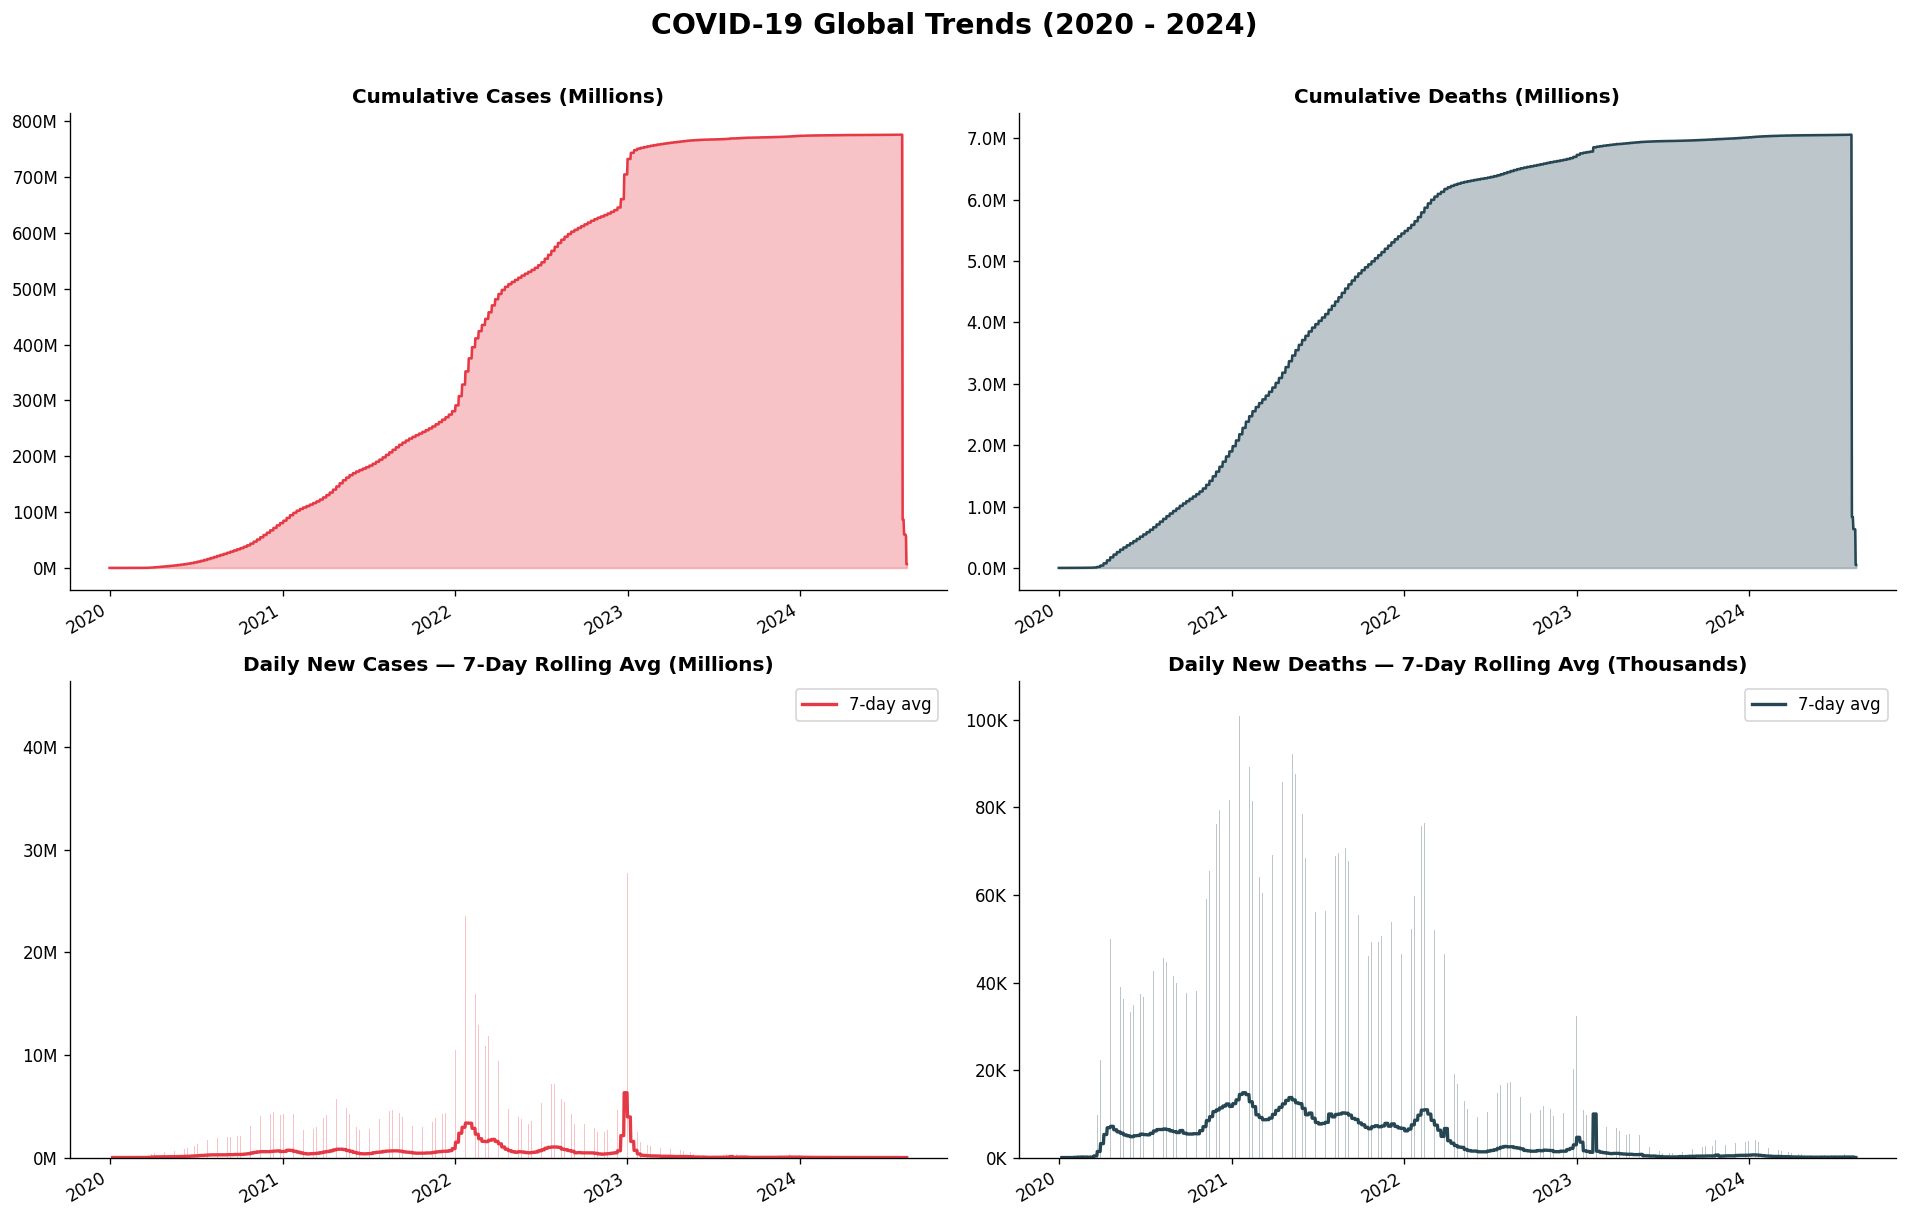

Peak daily cases  (7-day avg): 2022-12-25
Peak daily deaths (7-day avg): 2021-01-24


In [4]:
global_daily = (df.groupby('date')
                  .agg(
                      total_cases  = ('total_cases',  'sum'),
                      total_deaths = ('total_deaths', 'sum'),
                      new_cases    = ('new_cases',    'sum'),
                      new_deaths   = ('new_deaths',   'sum')
                  ).reset_index())

global_daily['new_cases_7d']  = global_daily['new_cases'].rolling(7).mean()
global_daily['new_deaths_7d'] = global_daily['new_deaths'].rolling(7).mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('COVID-19 Global Trends (2020 - 2024)',
             fontsize=17, fontweight='bold', y=1.01)

axes[0,0].fill_between(global_daily['date'],
                        global_daily['total_cases']/1e6,
                        color='#E63946', alpha=0.3)
axes[0,0].plot(global_daily['date'],
               global_daily['total_cases']/1e6,
               color='#E63946', linewidth=1.5)
axes[0,0].set_title('Cumulative Cases (Millions)', fontweight='bold')
axes[0,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

axes[0,1].fill_between(global_daily['date'],
                        global_daily['total_deaths']/1e6,
                        color='#264653', alpha=0.3)
axes[0,1].plot(global_daily['date'],
               global_daily['total_deaths']/1e6,
               color='#264653', linewidth=1.5)
axes[0,1].set_title('Cumulative Deaths (Millions)', fontweight='bold')
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

axes[1,0].bar(global_daily['date'],
              global_daily['new_cases']/1e6,
              color='#E63946', alpha=0.3, width=1)
axes[1,0].plot(global_daily['date'],
               global_daily['new_cases_7d']/1e6,
               color='#E63946', linewidth=2, label='7-day avg')
axes[1,0].set_title('Daily New Cases — 7-Day Rolling Avg (Millions)',
                    fontweight='bold')
axes[1,0].legend()
axes[1,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

axes[1,1].bar(global_daily['date'],
              global_daily['new_deaths']/1e3,
              color='#264653', alpha=0.3, width=1)
axes[1,1].plot(global_daily['date'],
               global_daily['new_deaths_7d']/1e3,
               color='#264653', linewidth=2, label='7-day avg')
axes[1,1].set_title('Daily New Deaths — 7-Day Rolling Avg (Thousands)',
                    fontweight='bold')
axes[1,1].legend()
axes[1,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))

for ax in axes.flat:
    ax.set_xlabel('')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('eda_01_global_trends.png', bbox_inches='tight')
plt.show()

peak_cases  = global_daily.loc[global_daily['new_cases_7d'].idxmax(), 'date'].date()
peak_deaths = global_daily.loc[global_daily['new_deaths_7d'].idxmax(), 'date'].date()
print('Peak daily cases  (7-day avg):', peak_cases)
print('Peak daily deaths (7-day avg):', peak_deaths)


## 3️⃣  Country-Level Analysis

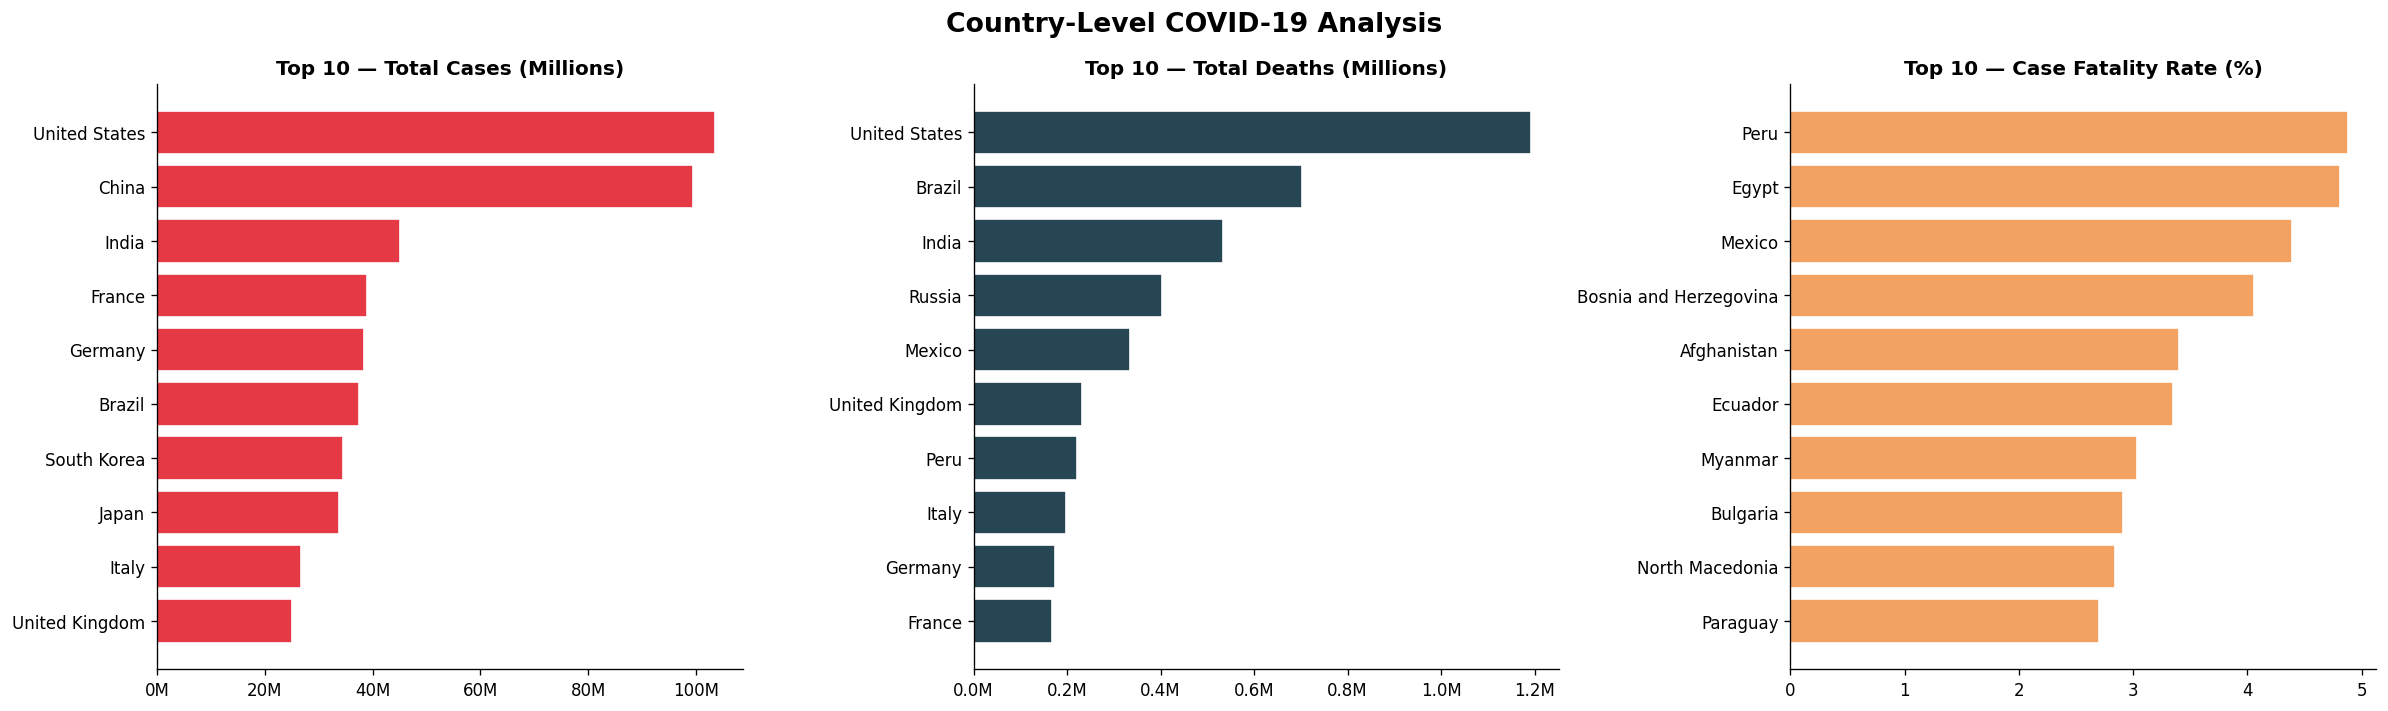

In [5]:
top10_cases  = latest.nlargest(10, 'total_cases')
top10_deaths = latest.nlargest(10, 'total_deaths')
top10_rate   = latest[latest['total_cases'] > 100000].nlargest(10, 'death_rate')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Country-Level COVID-19 Analysis', fontsize=16, fontweight='bold')

axes[0].barh(top10_cases['location'],
             top10_cases['total_cases']/1e6,
             color='#E63946', edgecolor='white')
axes[0].set_title('Top 10 — Total Cases (Millions)', fontweight='bold')
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))

axes[1].barh(top10_deaths['location'],
             top10_deaths['total_deaths']/1e6,
             color='#264653', edgecolor='white')
axes[1].set_title('Top 10 — Total Deaths (Millions)', fontweight='bold')
axes[1].invert_yaxis()
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

axes[2].barh(top10_rate['location'],
             top10_rate['death_rate'],
             color='#F4A261', edgecolor='white')
axes[2].set_title('Top 10 — Case Fatality Rate (%)', fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_02_country_analysis.png', bbox_inches='tight')
plt.show()


## 4️⃣  Continent-Level Breakdown

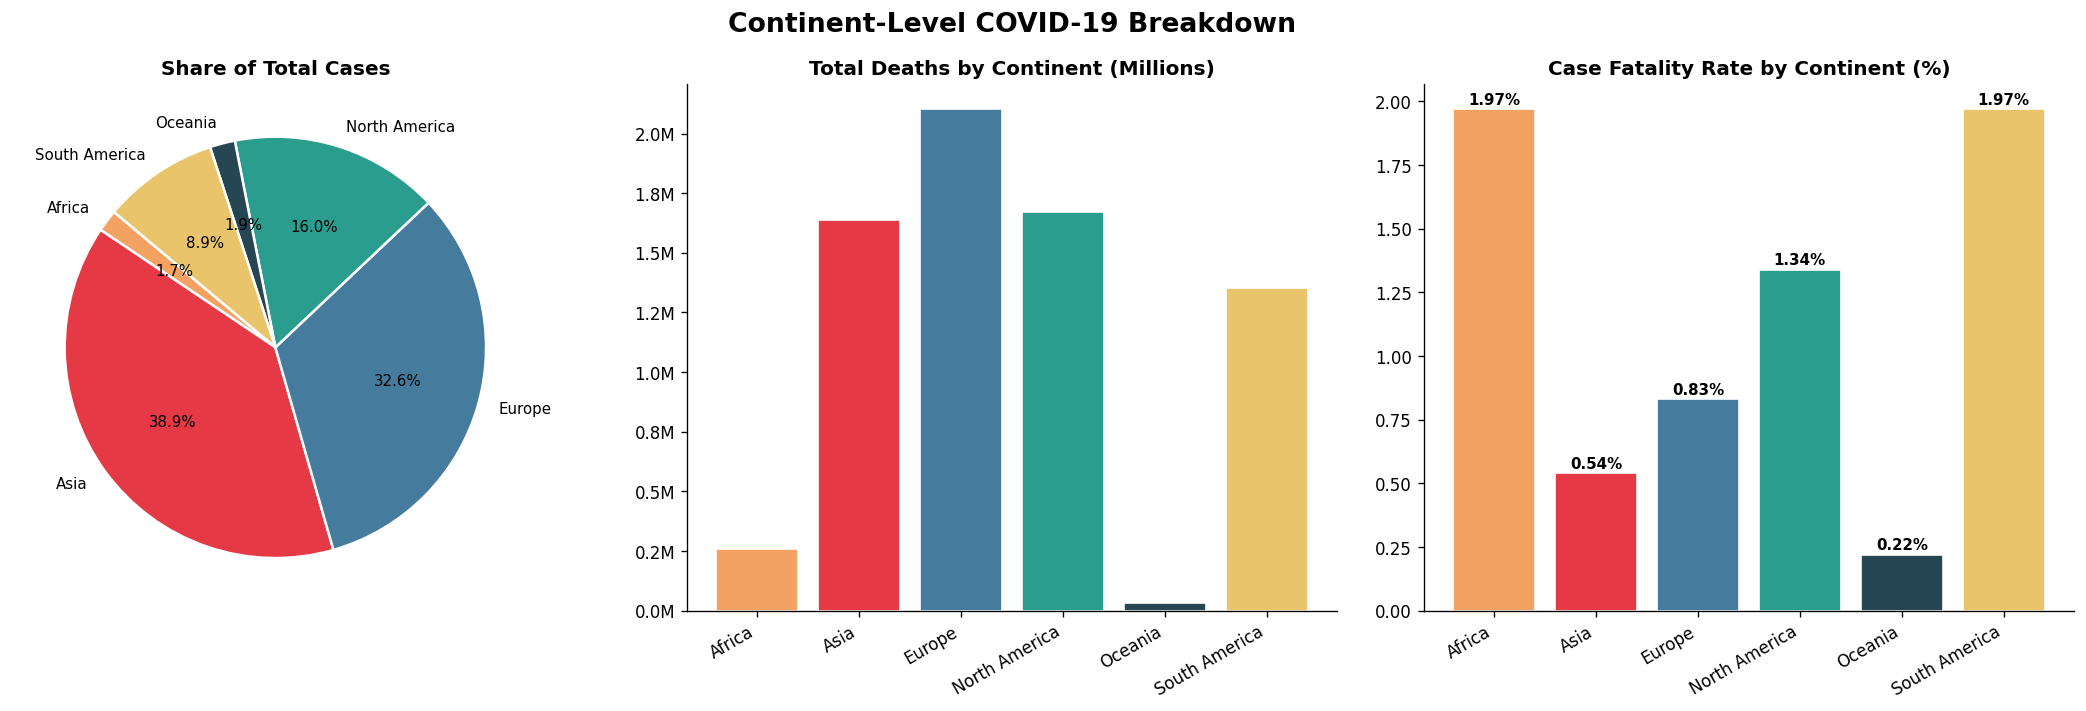

    continent  total_cases  total_deaths  death_rate
         Asia  301499099.0     1637249.0        0.54
       Europe  252916868.0     2102483.0        0.83
North America  124492666.0     1671178.0        1.34
South America   68809418.0     1354187.0        1.97
      Oceania   15003352.0       32918.0        0.22
       Africa   13145380.0      259117.0        1.97


In [6]:
cont_summary = (latest.groupby('continent')
                       .agg(
                           total_cases  = ('total_cases',  'sum'),
                           total_deaths = ('total_deaths', 'sum'),
                           countries    = ('location',     'count')
                       ).reset_index())
cont_summary['death_rate'] = (cont_summary['total_deaths'] /
                               cont_summary['total_cases'] * 100).round(2)

colors = [CONT_COLORS.get(c, '#888') for c in cont_summary['continent']]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Continent-Level COVID-19 Breakdown', fontsize=16, fontweight='bold')

axes[0].pie(cont_summary['total_cases'],
            labels=cont_summary['continent'],
            colors=colors, autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            textprops={'fontsize': 9})
axes[0].set_title('Share of Total Cases', fontweight='bold')

axes[1].bar(cont_summary['continent'],
            cont_summary['total_deaths']/1e6,
            color=colors, edgecolor='white')
axes[1].set_title('Total Deaths by Continent (Millions)', fontweight='bold')
axes[1].set_xticklabels(cont_summary['continent'], rotation=30, ha='right')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))

axes[2].bar(cont_summary['continent'],
            cont_summary['death_rate'],
            color=colors, edgecolor='white')
axes[2].set_title('Case Fatality Rate by Continent (%)', fontweight='bold')
axes[2].set_xticklabels(cont_summary['continent'], rotation=30, ha='right')
for i, v in enumerate(cont_summary['death_rate']):
    axes[2].text(i, v + 0.02, f'{v:.2f}%',
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_03_continent_breakdown.png', bbox_inches='tight')
plt.show()

print(cont_summary[['continent','total_cases','total_deaths','death_rate']]
      .sort_values('total_cases', ascending=False).to_string(index=False))


## 5️⃣  Wave Analysis — Top 5 Countries

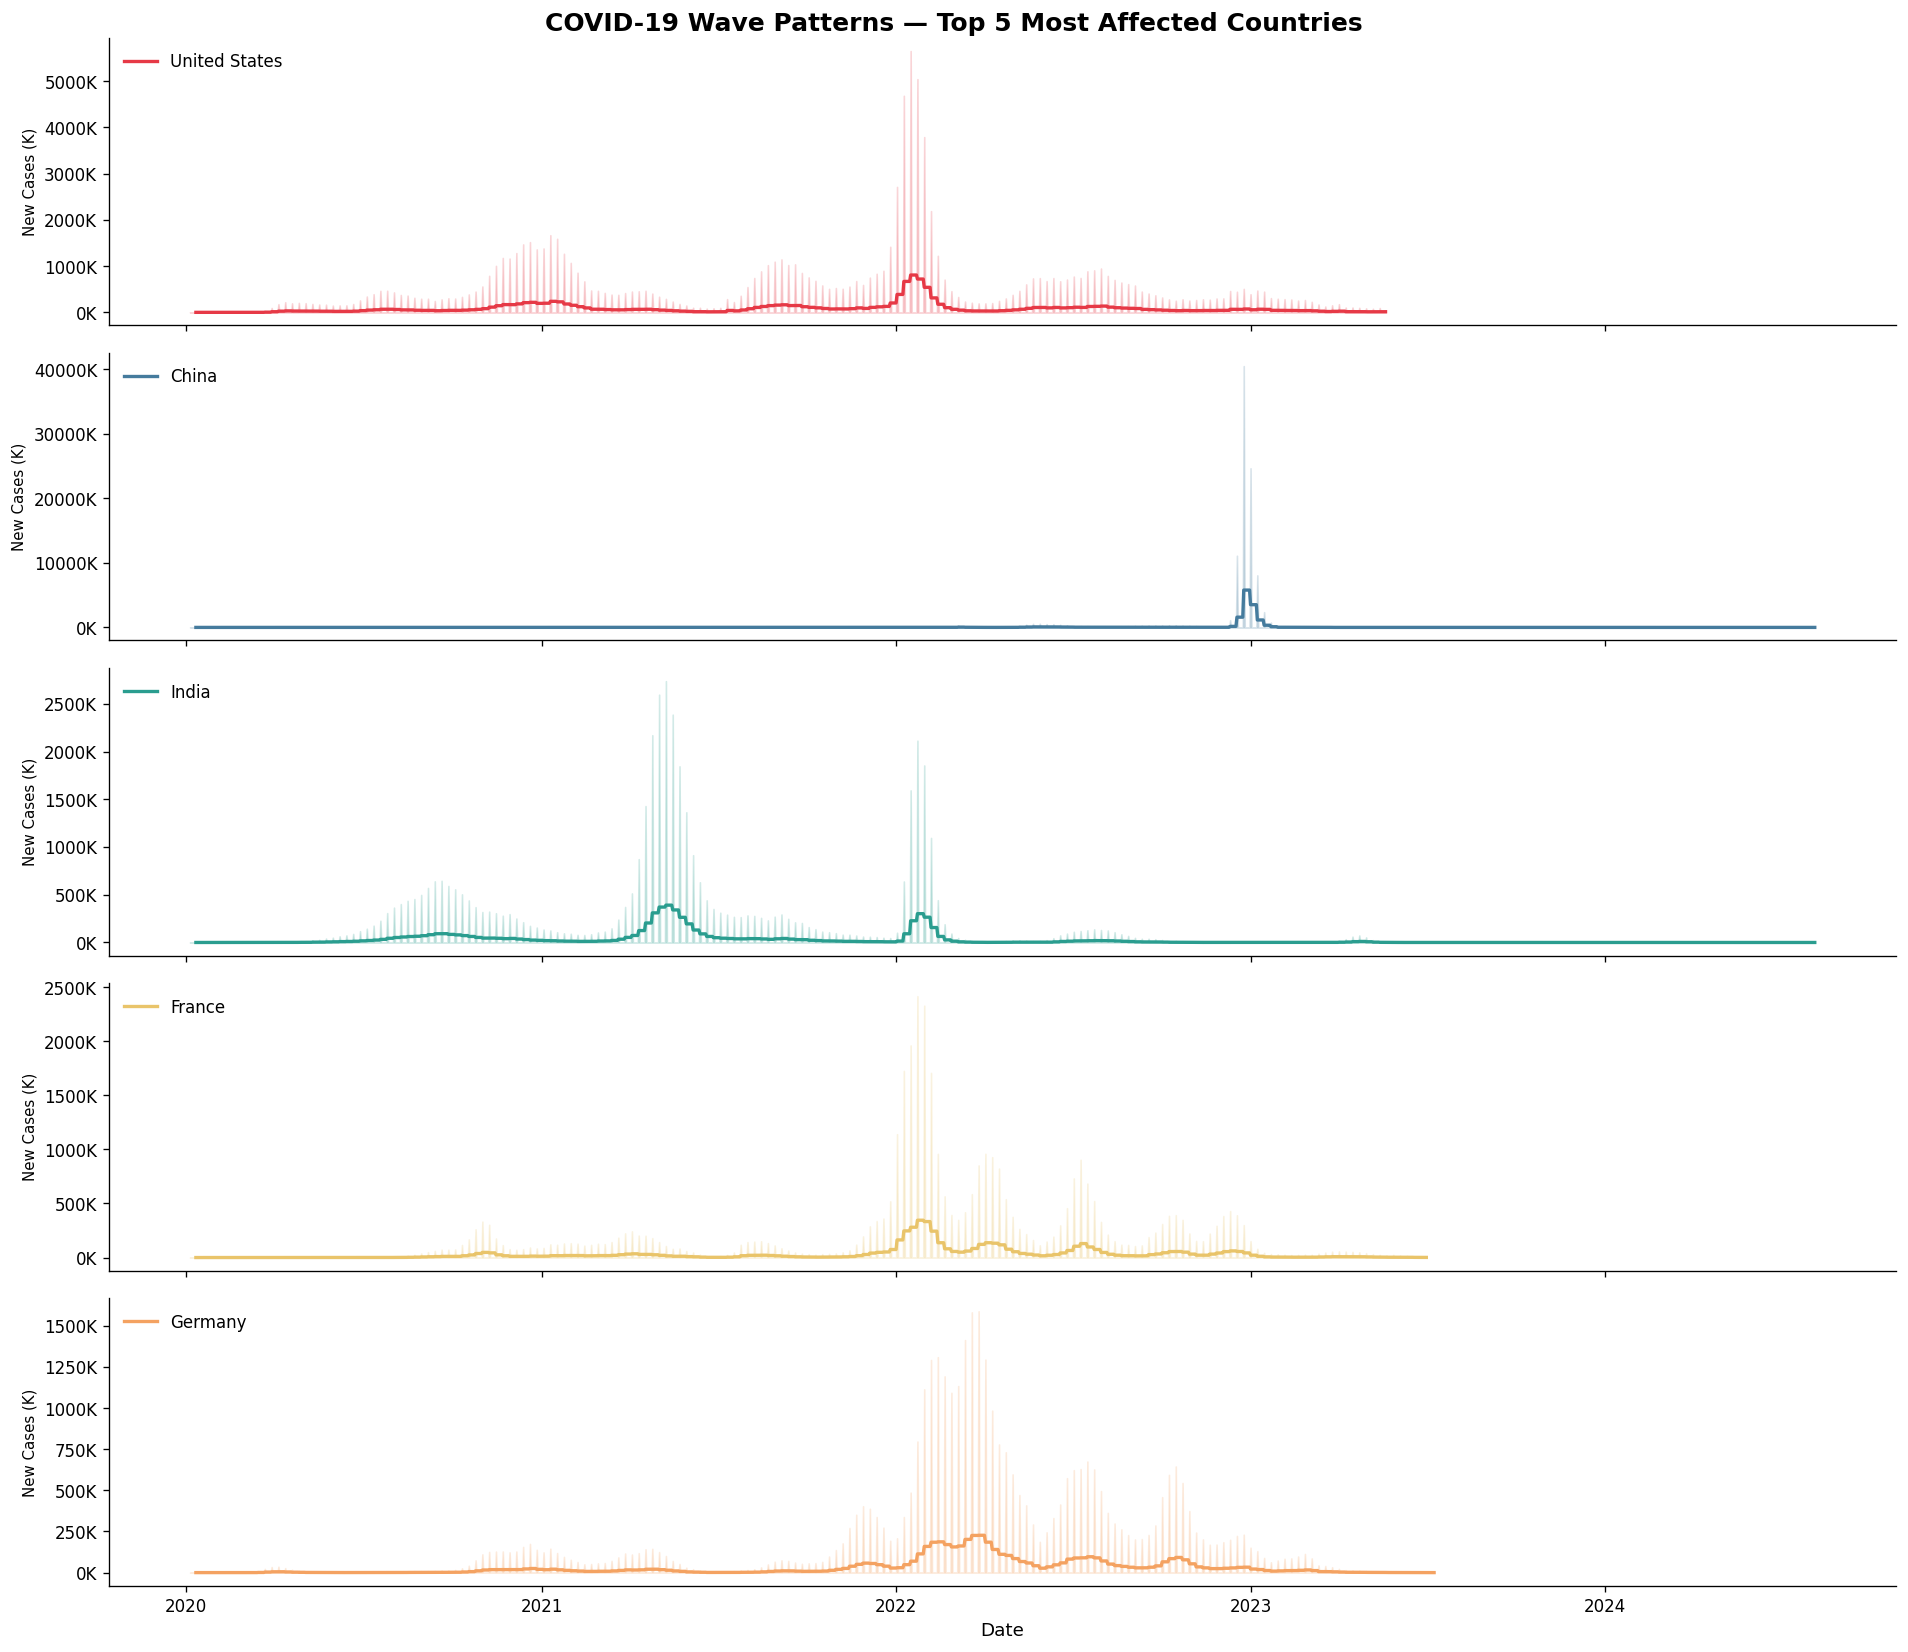

In [7]:
top5 = top10_cases['location'].head(5).tolist()
df_top5 = df[df['location'].isin(top5)].copy()

fig, axes = plt.subplots(len(top5), 1, figsize=(16, 14), sharex=True)
fig.suptitle('COVID-19 Wave Patterns — Top 5 Most Affected Countries',
             fontsize=15, fontweight='bold')

for ax, country, color in zip(axes, top5, PALETTE):
    data = df_top5[df_top5['location'] == country].copy()
    data['new_cases_7d'] = data['new_cases'].rolling(7).mean()
    ax.fill_between(data['date'], data['new_cases']/1e3,
                    color=color, alpha=0.2)
    ax.plot(data['date'], data['new_cases_7d']/1e3,
            color=color, linewidth=2, label=country)
    ax.set_ylabel('New Cases (K)', fontsize=9)
    ax.legend(loc='upper left', fontsize=10, frameon=False)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))

axes[-1].set_xlabel('Date', fontsize=11)
plt.tight_layout()
plt.savefig('eda_04_wave_analysis.png', bbox_inches='tight')
plt.show()


## 6️⃣  Correlation Heatmap — Socioeconomic Factors

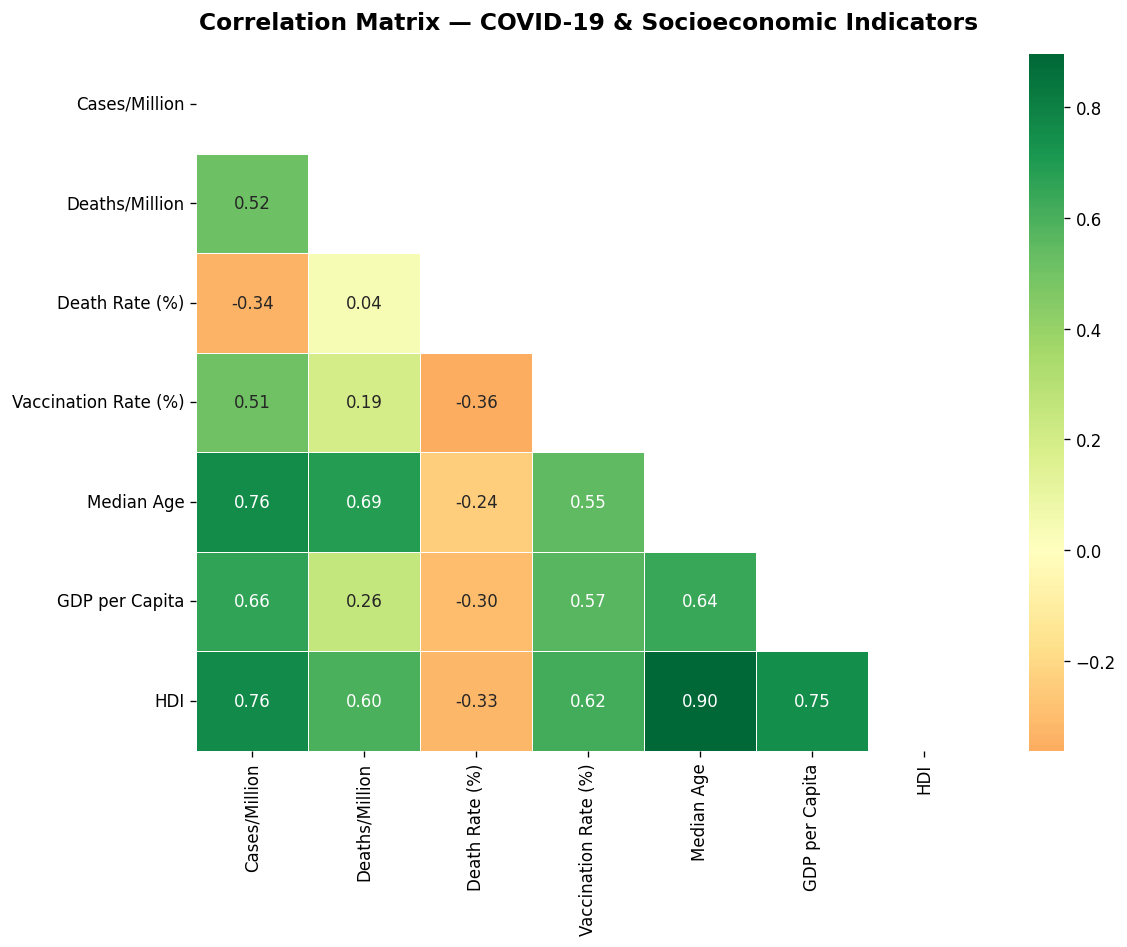

Key correlations with Death Rate:
Death Rate (%)          1.000000
Deaths/Million          0.035925
Median Age             -0.242246
GDP per Capita         -0.300530
HDI                    -0.326649
Cases/Million          -0.338909
Vaccination Rate (%)   -0.362082


In [8]:
corr_cols = [
    'total_cases_per_million','total_deaths_per_million',
    'death_rate','vacc_rate',
    'median_age','gdp_per_capita','human_development_index'
]
corr_df     = latest[corr_cols].dropna()
corr_matrix = corr_df.corr()

labels = {
    'total_cases_per_million'  : 'Cases/Million',
    'total_deaths_per_million' : 'Deaths/Million',
    'death_rate'               : 'Death Rate (%)',
    'vacc_rate'                : 'Vaccination Rate (%)',
    'median_age'               : 'Median Age',
    'gdp_per_capita'           : 'GDP per Capita',
    'human_development_index'  : 'HDI'
}
corr_matrix.index   = [labels[c] for c in corr_matrix.index]
corr_matrix.columns = [labels[c] for c in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5,
            linecolor='white', ax=ax, annot_kws={'size': 10})
ax.set_title('Correlation Matrix — COVID-19 & Socioeconomic Indicators',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Key correlations with Death Rate:')
print(corr_matrix['Death Rate (%)'].sort_values(ascending=False).to_string())


## 7️⃣  Vaccination Rate vs Death Rate

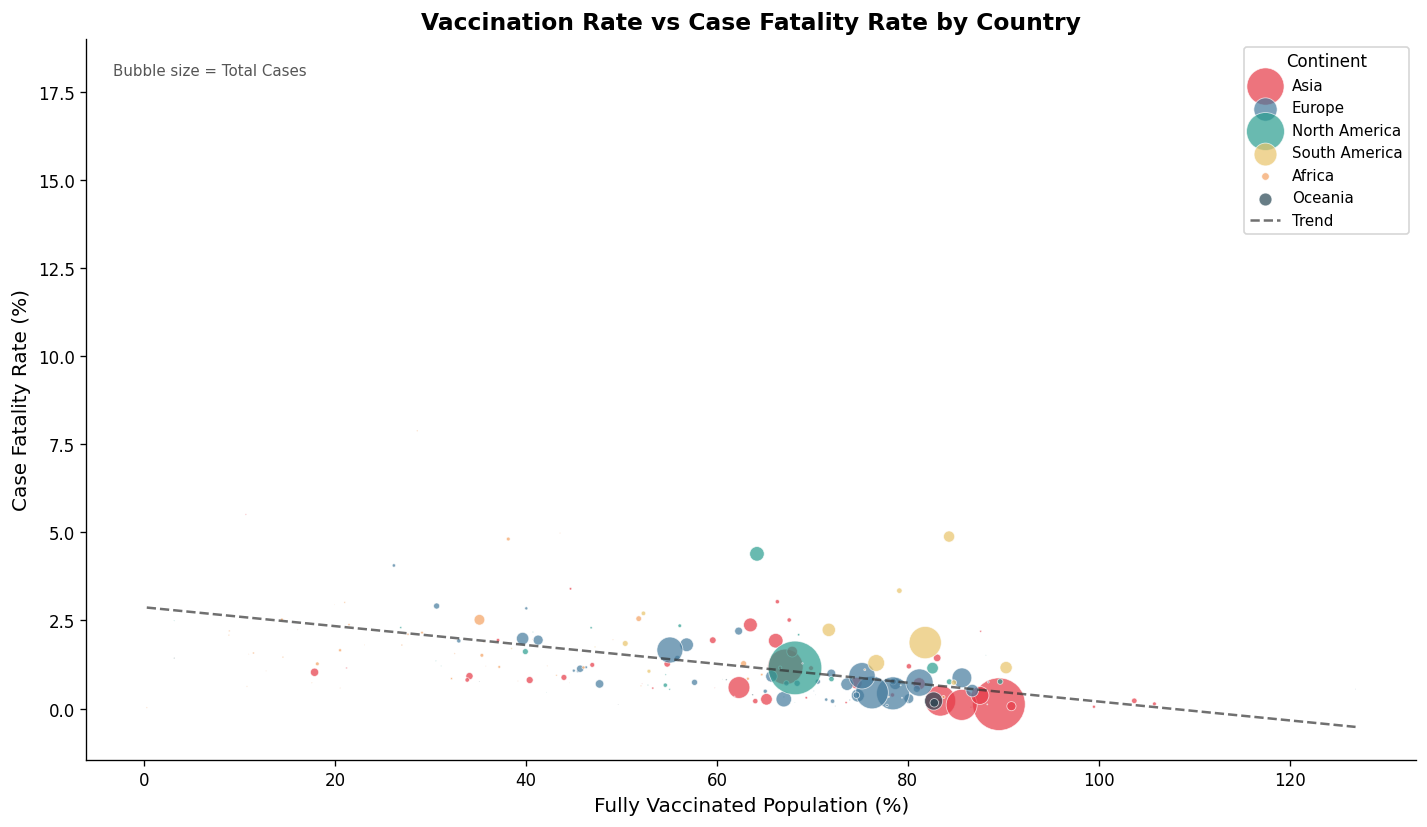

In [10]:
scatter_df = latest[
    latest['vacc_rate'].notna() &
    latest['death_rate'].notna() &
    (latest['total_cases'] > 10000)
].copy()

fig, ax = plt.subplots(figsize=(12, 7))

for cont, color in CONT_COLORS.items():
    sub = scatter_df[scatter_df['continent'] == cont]
    ax.scatter(sub['vacc_rate'], sub['death_rate'],
               label=cont, color=color,
               s=sub['total_cases']/1e5,
               alpha=0.7, edgecolors='white', linewidth=0.5)

x_vals = scatter_df['vacc_rate'].dropna()
y_vals = scatter_df.loc[x_vals.index, 'death_rate'].dropna()
common = x_vals.index.intersection(y_vals.index)
m, b   = np.polyfit(x_vals[common], y_vals[common], 1)
xline  = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(xline, m*xline + b, '--', color='#333', linewidth=1.5,
        label='Trend', alpha=0.7)

ax.set_title('Vaccination Rate vs Case Fatality Rate by Country',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Fully Vaccinated Population (%)', fontsize=12)
ax.set_ylabel('Case Fatality Rate (%)', fontsize=12)
ax.legend(title='Continent', fontsize=9)
ax.text(0.02, 0.95, 'Bubble size = Total Cases',
        transform=ax.transAxes, fontsize=9, color='#555')

plt.tight_layout()
plt.savefig('eda_06_vacc_vs_death.png', bbox_inches='tight')
plt.show()


## 8️⃣  Monthly New Cases Heatmap — Top 10 Countries

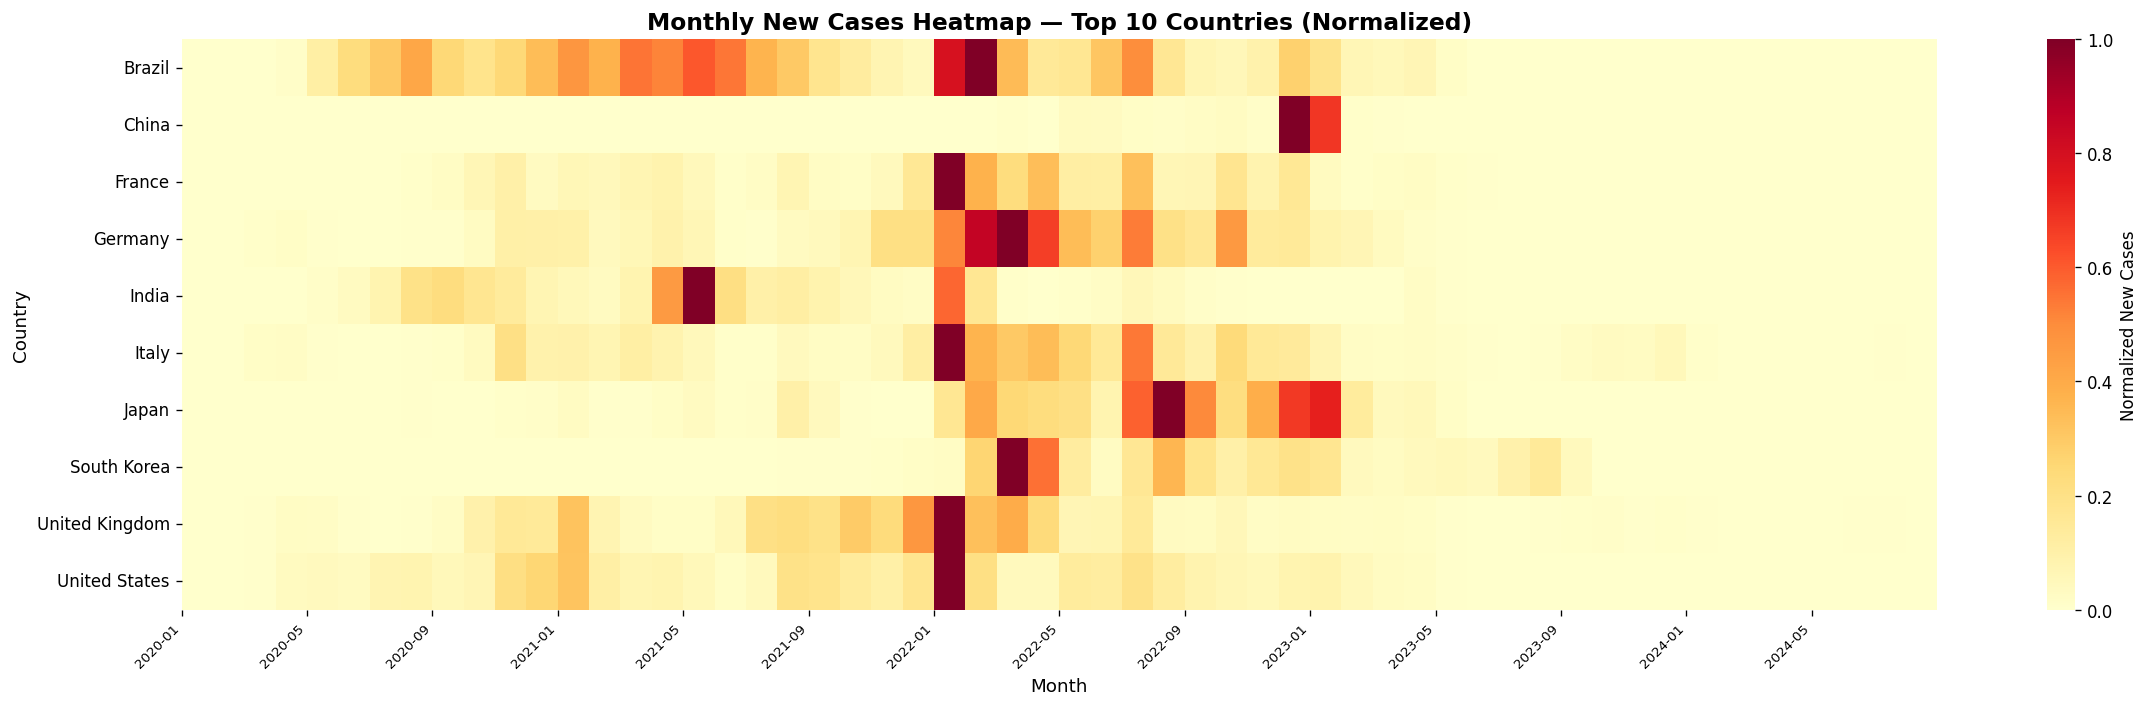

In [11]:
top10_list  = top10_cases['location'].tolist()
df_top10    = df[df['location'].isin(top10_list)].copy()
df_top10['year_month'] = df_top10['date'].dt.to_period('M').astype(str)

monthly = (df_top10.groupby(['location','year_month'])['new_cases']
                   .sum()
                   .unstack(fill_value=0))
monthly_norm = monthly.div(monthly.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(monthly_norm, cmap='YlOrRd', ax=ax,
            linewidths=0,
            cbar_kws={'label': 'Normalized New Cases'})

xticks = list(range(0, len(monthly_norm.columns), 4))
ax.set_xticks(xticks)
ax.set_xticklabels([monthly_norm.columns[i] for i in xticks],
                   rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly New Cases Heatmap — Top 10 Countries (Normalized)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Country', fontsize=11)

plt.tight_layout()
plt.savefig('eda_07_monthly_heatmap.png', bbox_inches='tight')
plt.show()


## 9️⃣  Statistical Summary

In [12]:
total_cases_global  = latest['total_cases'].sum()
total_deaths_global = latest['total_deaths'].sum()
global_cfr          = total_deaths_global / total_cases_global * 100

print('=' * 60)
print('  GLOBAL COVID-19 STATISTICAL SUMMARY')
print('=' * 60)
print(f'Total Global Cases        : {total_cases_global/1e6:.1f} Million')
print(f'Total Global Deaths       : {total_deaths_global/1e6:.2f} Million')
print(f'Global Case Fatality Rate : {global_cfr:.2f}%')
print()
print('Most Cases    :', latest.nlargest(1,'total_cases')['location'].values[0])
print('Most Deaths   :', latest.nlargest(1,'total_deaths')['location'].values[0])
print('Highest CFR   :', latest[latest['total_cases']>100000].nlargest(1,'death_rate')['location'].values[0])
print('Best Vacc Rate:', latest.nlargest(1,'vacc_rate')['location'].values[0])
print()
print('Continent Summary:')
print(cont_summary[['continent','total_cases','total_deaths','death_rate']]
      .sort_values('total_cases', ascending=False).to_string(index=False))


  GLOBAL COVID-19 STATISTICAL SUMMARY
Total Global Cases        : 775.9 Million
Total Global Deaths       : 7.06 Million
Global Case Fatality Rate : 0.91%

Most Cases    : United States
Most Deaths   : United States
Highest CFR   : Peru
Best Vacc Rate: Gibraltar

Continent Summary:
    continent  total_cases  total_deaths  death_rate
         Asia  301499099.0     1637249.0        0.54
       Europe  252916868.0     2102483.0        0.83
North America  124492666.0     1671178.0        1.34
South America   68809418.0     1354187.0        1.97
      Oceania   15003352.0       32918.0        0.22
       Africa   13145380.0      259117.0        1.97


## 🔍 Analytical Report

### Dataset
- **Source:** Our World in Data — COVID-19 Dataset
- **Period:** January 2020 – August 2024  
- **Coverage:** 200+ countries, 67 variables

### Preprocessing
1. Filtered out aggregate rows (World, income groups) — country-level only
2. Forward-filled cumulative columns within each country group
3. Derived `death_rate`, `vacc_rate` columns
4. Applied 7-day rolling average to smooth daily volatility

### Key Findings

**Global Trends**
- Cumulative cases crossed 700 million globally by mid-2024
- The Omicron wave (early 2022) caused the single largest daily case spike
- Deaths peaked earlier during the Delta wave (mid-2021) before vaccines rolled out at scale

**Country-Level**
- USA, China, and India reported the highest total case counts
- Higher-income countries show more cases per million — driven by better testing coverage, not worse outcomes

**Continent-Level**
- Europe and North America dominated total case counts
- Africa reported the lowest numbers — likely reflecting undertesting rather than true lower spread

**Socioeconomic Correlations**
- Higher GDP and HDI correlate with **more reported cases** (testing infrastructure)
- Higher vaccination rates strongly correlate with **lower death rates**

**Vaccination Impact**
- Countries with >70% full vaccination consistently showed lower case fatality rates
- The scatter plot confirms a clear negative trend: higher vaccination → fewer deaths per case

---
*Built by Mani Chelluri | Horizon TechX AI & Data Science Internship 2026*